In [1]:
import sys, os
sys.path.append('../MultiFishLSS/')
from headers import *
from twoPoint import *
from twoPointNoise import *
from classy import Class

import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', serif='Computer Modern Roman')

plt.rcParams.update({
    "font.size": 16,        # default text size
    "axes.titlesize": 18,   # title
    "axes.labelsize": 18,   # x and y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

import os
os.environ["PATH"] += os.pathsep + "/usr/local/texlive/2020/bin/x86_64-darwin"

## Generate BAO forecasts

#### Fiducial cosmology

In [ ]:
default_cosmo = {
        'output': 'tCl lCl mPk',
        'non linear':'halofit',
        'l_max_scalars': 4000,
        'lensing': 'yes',
        'A_s': 2.10732e-9,
        'n_s': 0.96824,
        'alpha_s': 0.,
        'h': 0.6770,
        'N_ur': 1.0196,
        'N_ncdm': 2,
        'm_ncdm': '0.01,0.05',
        'tau_reio': 0.0568,
        'omega_b': 0.02247,
        'omega_cdm': 0.11923,
        'Omega_k': 0.,
        'P_k_max_h/Mpc': 2.,
        'z_pk': '0.0,6'}

cosmo = Class()
cosmo.set(default_cosmo)
cosmo.compute()

#### Experiment configuration to reproduce FishLSS DESI ELG results but using wigglesplit recon.

In [ ]:
fsky = 0.34

bd = './'
sfb = 'desi2_elg'
file_dir = '../DESI2_scripts/'

zs, bs, ns = np.loadtxt(file_dir + sfb+".txt").T
zmin = round(0.1*int(ceil(zs[0]*10)),4)
zmax = round(0.1*int(zs[-1]*10),4)
N = round((zmax-zmin)/0.2)+1

zedg = np.linspace(zmin,zmax,N,endpoint=True)
# 2 galaxy samples 
# name, bias, number density as lists
# Interpolate the bias and number density
b = interp1d(zs,bs)
n = interp1d(zs,ns)

# Set up the experiment object.
exp = experiment(zedges=zedg,fsky=fsky,b=b,n=n)

recon = 'wigglesplit'

#kmax = 0.6

surveyname = '{}_kmin{}_kmax{}_{}_AP_C_Pw'.format(recon, 'kmin', 'kmax',sfb)

overwrite = True

#recon_sigmas = {'sigmaS':2., 'sigmaPar':4.5, 'sigmaPerp':2.5}

# May need to turn recon off here and turn it back on later otherwise the fiducial Pk is the Precon?
wsforecast = fisherForecast(experiment=exp,cosmo=cosmo,name=surveyname,basedir=bd, recon=recon,overwrite=overwrite)    

Initialising fiducial Pk with recon = wigglesplit and self.recon = False
Finished computing fiducial Pk, setting self.recon = wigglesplit
Initialising fiducial Precon with recon = wigglesplit and self.recon = wigglesplit
sigmas: 2.0 3.8283462271097113 2.143250283054121
2.0 3.8283462271097113 2.143250283054121
Using simpson integration
sigmas: 2.0 3.575418591929476 1.9478436475089052
2.0 3.575418591929476 1.9478436475089052
Using simpson integration
sigmas: 2.0 3.33243697389511 1.7801628300956807
2.0 3.33243697389511 1.7801628300956807
Using simpson integration
sigmas: 2.0 3.106692775744917 1.636023564703587
2.0 3.106692775744917 1.636023564703587
Using simpson integration
sigmas: 2.0 2.900758236126764 1.5115680236430062
2.0 2.900758236126764 1.5115680236430062
Using simpson integration
Finished computing fiducial Precon, setting self.recon = wigglesplit


### Compute derivatives. For wigglesplit, compute derivative w.r.t. $P_\text{w}$ only to avoid AP parameter information leakage from broadband.
Derivatives are computed faster with dedicated node, using `example_setup.sh`

Turn `forecast.recon` to `True` to work on BAOs

In [27]:
%reload_ext autoreload
%autoreload 2

basis = np.array(['alpha_parallel','alpha_perp','b'])

wsforecast.free_params = basis
wsforecast.compute_derivatives(overwrite=True) # will not overwrite unless specified

sigmas: 2.0 3.8283462271097113 2.143250283054121
2.0 3.8283462271097113 2.143250283054121
[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000

#### Use derivatives to construct Fisher matrix and get forecasts

In [ ]:
wsF = lambda i: wsforecast.gen_fisher(basis, 100,zbins=np.array([i]))
wsFs = [wsF(i) for i in range(nbins)]
wsFs = np.array(wsFs)

marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method
marginalising splines new method


### Add loose prior on spline amplitudes to regularise so that n>ceil( (kmin-kmax)/delta ) spline amplitudes doesn't give singular matrix.

In [29]:
# prior = 1e-4

# for fish in wsFs:
#     for i in range(len(basis), len(fish)):
#         print(fish[i,i])
#         fish[i,i] += prior**(-2)

# print(wsFs[2])

In [38]:
wsFinvs = [np.linalg.inv(wsFs[i]) for i in range(nbins)]
wssaparr = np.array([np.sqrt(wsFinvs[i][0,0]) for i in range(nbins)])
wssaperp = np.array([np.sqrt(wsFinvs[i][1,1]) for i in range(nbins)])

print('Relative error on a_par:',wssaparr)
print('Relative error on a_perp:',wssaperp)


Relative error on a_par: [0.0292304  0.00949758 0.00716396 0.00699739 0.0071554 ]
Relative error on a_perp: [0.02640122 0.00669159 0.00507107 0.00511002 0.00514929]


#### Percent difference in constraints computed as $100\times \frac{|\Delta \alpha|}{\alpha}$ where $\alpha$ is evaluated at its fiducial value $\alpha=1$. Matches expectations from DESI 2024 theory paper.

In [32]:
w_apar = np.array([0.02940135, 0.00945302, 0.00720717, 0.00699512, 0.00722142])
w_aperp = np.array([0.02645817, 0.00667335, 0.00507783, 0.00515775, 0.00548597])

w_nw_apar = np.array([0.02939751, 0.00945656, 0.00721347, 0.00699979, 0.00718917])
w_nw_aperp = np.array([0.02648029, 0.00667514, 0.0050908,  0.00512311, 0.00527006])

print(np.max(np.abs(100*(w_nw_apar - w_apar))))
print(np.max(np.abs(100*(w_nw_aperp - w_aperp))))

0.003225000000000016
0.02159099999999997


### Import LPT forecast to compare constraints

In [8]:
recon = 'LPT'

surveyname = '{}_kmin{}_kmax{}_{}'.format(recon, 'kmin', 'kmax',sfb)

# May need to turn recon off here and turn it back on later otherwise the fiducial Pk is the Precon?
LPTforecast = fisherForecast(experiment=exp,cosmo=cosmo,name=surveyname,basedir=bd, recon=recon)    

Initialising fiducial Pk with recon = LPT and self.recon = False
Finished computing fiducial Pk, setting self.recon = LPT
Initialising fiducial Precon with recon = LPT and self.recon = LPT
Finished computing fiducial Precon, setting self.recon = LPT


In [9]:
LPTforecast.free_params = basis
LPTforecast.compute_derivatives()

LPTF = lambda i: LPTforecast.gen_fisher(basis, 100, zbins=np.array([i]))
LPTFs = [LPTF(i) for i in range(nbins)]
LPTFs = np.array(LPTFs)

marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys
marginalising polys


#### Testing adding prior on polynomial broadband terms.

In [10]:
# for fish in LPTFs:
#     for i in range(len(basis), len(fish)):
#         print(fish[i,i])
#         fish[i,i] += prior**(-2)

# print(LPTFs[2])

In [11]:
LPTFinvs = [np.linalg.inv(LPTFs[i]) for i in range(nbins)]
LPTsaparr = np.array([np.sqrt(LPTFinvs[i][0,0]) for i in range(nbins)])
LPTsaperp = np.array([np.sqrt(LPTFinvs[i][1,1]) for i in range(nbins)])

print('Relative error on a_par:',LPTsaparr)
print('Relative error on a_perp:',LPTsaperp)

Relative error on a_par: [0.0339813  0.01017575 0.00819413 0.0081461  0.008333  ]
Relative error on a_perp: [0.02859818 0.00689108 0.0054186  0.00552324 0.0058299 ]


### Plot fractional difference as function of redshift

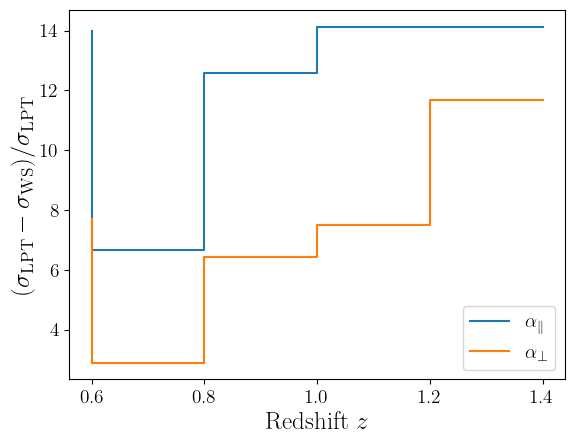

In [ ]:
prat_saparr = 100*(LPTsaparr - wssaparr)/LPTsaparr

prat_saperp = 100*(LPTsaperp - wssaperp)/LPTsaperp

zs = wsforecast.experiment.zcenters

plt.step(zs, prat_saparr, label=r'$\alpha_\|$')
plt.step(zs, prat_saperp, label=r'$\alpha_\perp$')
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$(\sigma_\mathrm{LPT}-\sigma_\mathrm{WS})/\sigma_\mathrm{LPT}$')
plt.legend()
#plt.savefig('/Users/makaibaker/Dropbox/2026/Berkeley/Research/sigmaAP_comparison.pdf')
plt.show()

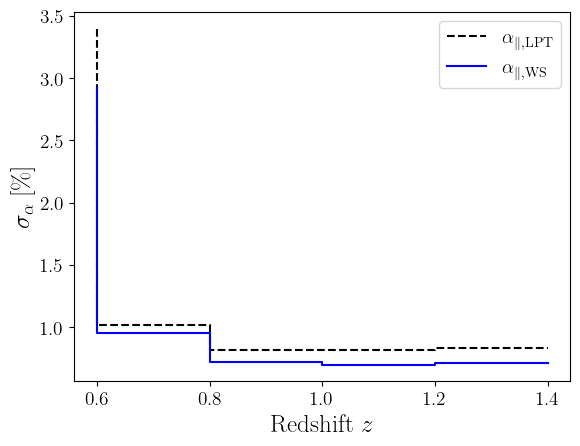

In [ ]:
plt.step(zs, 100*LPTsaparr, color='black', ls='--', label=r'$\alpha_{\|,\mathrm{LPT}}$')
plt.step(zs, 100*wssaparr, color='blue', ls='-', label=r'$\alpha_{\|,\mathrm{WS}}$')
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$\sigma_\alpha \; [\%]$')
plt.legend()
plt.show()

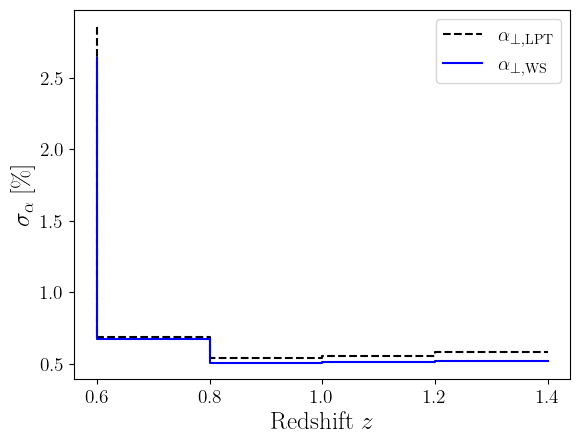

In [37]:
plt.step(zs, 100*LPTsaperp, color='black', ls='--', label=r'$\alpha_{\perp,\mathrm{LPT}}$')
plt.step(zs, 100*wssaperp, color='blue', ls='-', label=r'$\alpha_{\perp,\mathrm{WS}}$')
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$\sigma_\alpha \; [\%]$')
plt.legend()
plt.show()

### Transform to $\alpha_\text{iso}, \alpha_{\text{AP}}$ basis using Fisher transformation matrix.

##### First define transformation matrix

In [13]:
def ap_transformation(forecast, Fs):
    saiso = [] 
    saap = []

    for i in range(len(Fs)):

        F = Fs[i] #basis a_par, a_perp -> a_iso, a_AP
        M = np.eye(F.shape[0])

        z = forecast.experiment.zcenters[i]

        a_perp = 1. #forecast.cosmo.angular_distance(z)*forecast.cosmo.h() / forecast.Da_fid(z) 
        a_par = 1. #forecast.Hz_fid(z)/(forecast.cosmo.Hubble(z)*(299792.458)/forecast.cosmo.h())

        daiso_daperp = 2./3. * (a_par / a_perp)**(1./3.)
        daiso_dapar = 1./3. * (a_perp / a_par)**(2./3.)

        daap_daperp = -a_par/a_perp**2
        daap_dapar = 1/a_perp

        #Compute Jacobian = dold/dnew, but new params  = func(old), so compute dnew/dold and invert

        M[0,0] = daiso_dapar 
        M[0,1] = daiso_daperp 
        
        M[1,0] = daap_dapar 
        M[1,1] = daap_daperp 

        M = np.linalg.inv(M)
        print(M)

        Fnew = M.T @ F @ M
        
        Fnewinv = np.linalg.inv(Fnew)

        covnew = Fnewinv[:2,:2]

        saiso += [np.sqrt(covnew[0,0])]
        saap += [np.sqrt(covnew[1,1])]

    return np.array(saiso), np.array(saap)


In [14]:
wssaiso, wssaap = ap_transformation(wsforecast, wsFs)
lptsaiso, lptsaap = ap_transformation(LPTforecast, LPTFs)

[[ 1.          0.66666667  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 1.         -0.33333333  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          1.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        

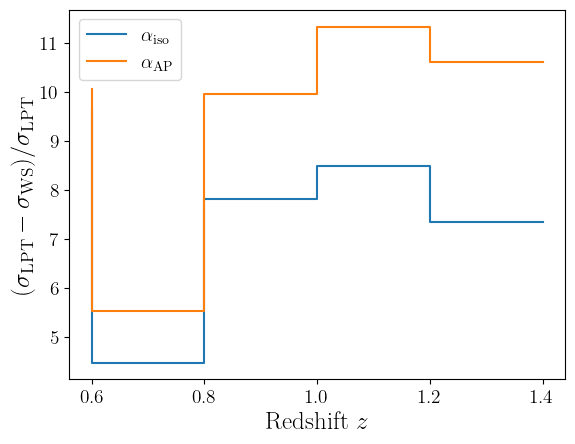

In [15]:
prat_saiso = 100*(lptsaiso - wssaiso)/lptsaiso

prat_saap = 100*(lptsaap - wssaap)/lptsaap

zs = wsforecast.experiment.zcenters

plt.step(zs, prat_saiso, label=r'$\alpha_\mathrm{iso}$')
plt.step(zs, prat_saap, label=r'$\alpha_\mathrm{AP}$')
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$(\sigma_\mathrm{LPT}-\sigma_\mathrm{WS})/\sigma_\mathrm{LPT}$')
plt.legend()
plt.show()

In [16]:
z=1.
print(cosmo.sigma8())
sperp = 12.4 * 0.758 * cosmo.sigma(8,z,h_units=True)/0.9

kk = np.logspace(np.log10(wsforecast.kmin),np.log10(wsforecast.kmax),wsforecast.Nk)
pmatter = np.array([wsforecast.cosmo.pk_cb_lin(k*wsforecast.cosmo.h(),z)*wsforecast.cosmo.h()**3. for k in kk])

sperp_man = np.sqrt(np.trapezoid(pmatter, kk) / (6*np.pi**2))

sperp_fsh = np.sqrt(wsforecast.Sigma2(z))

pmatterz0 = np.array([wsforecast.cosmo.pk_cb_lin(k*wsforecast.cosmo.h(),0)*wsforecast.cosmo.h()**3. for k in kk])
sigma0 = np.sqrt(np.trapezoid(pmatterz0, kk) / (6*np.pi**2))

sperp_angbao = sigma0 * cosmo.scale_independent_growth_factor(z)


print(sperp, sperp_man, sperp_fsh, sperp_angbao)
print(sperp_fsh - sperp_man)



0.8108494016644784
5.157380994995924 3.5369443727262984 3.559693432525566 3.5375727060049624
0.022749059799267446


In [17]:
"""
To compare to Fig. 10 of Noah's paper may have to convert errors from DA/rd Hrd to a_\perp a_\| (i.e. the errors might be misinterpreted)? Would introduce redshift dependence.
"""
plt.plot(zs, saparr, marker='s', color='blue', label = r'$\sigma_{\alpha_\|}$')
plt.plot(zs, saperp, marker='s', color='orange', label = r'$\sigma_{\alpha_\perp}$')
plt.plot(zs, saiso, marker='+', color='red', linestyle=':', label = r'$\sigma_{\alpha_\mathrm{iso}}$')
plt.plot(zs, saap, marker='+', color='black',linestyle=':',  label = r'$\sigma_{\alpha_\mathrm{AP}}$')
plt.xlabel('Redshift z')
plt.ylabel(r'Error $\sigma$')
plt.legend()
plt.show()

NameError: name 'saparr' is not defined

In [ ]:
zone = forecast.experiment.zcenters == 1
saperp = np.array(saperp)
saparr = np.array(saparr)
print(saperp[zone], saparr[zone])

### Old code: Ignore

In [ ]:
# from matplotlib.patches import Ellipse

# for i in range(nbins):
#     F = Fs[i]
#     Finv = np.linalg.inv(F)
#     z = forecast.experiment.zcenters[i]

#     a_perp = forecast.cosmo.angular_distance(z)*forecast.cosmo.h() / forecast.Da_fid(z) 
#     a_par = forecast.Hz_fid(z)/(forecast.cosmo.Hubble(z)*(299792.458)/forecast.cosmo.h())

#     sigmasq_par = Finv[0,0]
#     sigmasq_perp = Finv[1,1]
#     sigma_isoAP = Finv[0,1]

#     print('Relative error on a_iso:',np.sqrt(sigmasq_iso), ' for bin', i)
#     print('Relative error on a_AP:',np.sqrt(sigmasq_AP), ' for bin', i)

#     asq = (sigmasq_iso + sigmasq_AP)/2. + np.sqrt( (sigmasq_iso - sigmasq_AP)**2/4. + sigma_isoAP**2)
#     bsq = (sigmasq_iso + sigmasq_AP)/2. - np.sqrt( (sigmasq_iso - sigmasq_AP)**2/4. + sigma_isoAP**2)
#     tantwotheta = 2*sigma_isoAP / (sigmasq_iso - sigmasq_AP) 

#     theta_rad = np.arctan(tantwotheta)/2. 
#     theta = theta_rad * 180./ np.pi

#     alphas = [1.52, 2.48]
#     transparency = [1., 0.5]
    
#     fig, ax = plt.subplots()
#     ax.set(xlim=(a_iso-3*np.sqrt(asq), a_iso + 3*np.sqrt(asq)), ylim=(a_AP-3*np.sqrt(bsq), a_AP+3*np.sqrt(bsq)))
    
#     for j in range(len(alphas)):
#         alpha = alphas[j]
#         t = transparency[j]

#         a = np.sqrt(asq) * alpha 
#         b = np.sqrt(bsq) * alpha

#         ellipse = Ellipse((a_iso, a_AP), 2*a, 2*b, angle=theta, alpha=t)

#         ax.add_artist(ellipse)

#     plt.xlabel(r"$\alpha_{\mathrm{iso}}$")
#     plt.ylabel(r"$\alpha_{\mathrm{AP}}$")
#     plt.tight_layout()
#     plt.show()

In [ ]:
mu = np.linspace(0.,1.,50)
k = np.logspace(np.log10(5e-4),np.log10(1.),500)

def W3(x):
    """
    W3 is the piecewise cubic spline (4th-order) extension of the counts-in-cell interpolation kernel (Hockney & Eastwood 1988; Jeong 2010).
    """
    absx = np.abs(x)

    ret = np.zeros_like(absx, dtype=float)

    #region 1
    mask1 = absx <= 1
    ret[mask1] = 4 - 6 * absx[mask1]**2  + 3 * absx[mask1]**3 
    
    #region 2
    mask2 = (absx > 1) & (absx <=2)
    ret[mask2] = 8 - 12 * absx[mask2]  + 6 * absx[mask2]**2 - absx[mask2]**3 

    return 1./6. * ret

def initialise_splines(k, N_splines=7, delta=0.06):
    """
    Initiialise the broadband splines. For broadband term 
    
    D_ell = \sum_{n=-1} ^ {N_\max} a_{\ell, n} W3(k/\delta - n)

    We have that for fiducial values of a_{\ell, n} = 1 (our choice), 

    D_0 = D_2 = D_4 = \sum_{n=-1} ^ {N_\max} W3(k/\delta - n)

    And dP/da_{\ell,n} = W3(n)*\mathcal{L}_\ell(\mu) 
    
    So the derivative for all ell is same as adding 
    
    D_0 * ( \mathcal{L}_0(\mu) + \mathcal{L}_2(\mu) + \mathcal{L}_4(\mu) ).

    We keep the values as an n by mu*k array so we can use it for derivatives (access each n)
    and for the broadband term in wiggle_split_recon (sum array along n).
    """
    arr = np.zeros( (N_splines, len(k)) )

    for n in range(N_splines):
        arr[n] = W3(k/delta - (n - 1))

    return arr

In [ ]:
l_sum = np.sum(legendre(2*i)(mu) for i in range(3))
N_splines = 7
splines = initialise_splines(k, N_splines=N_splines)

derivatives = np.zeros((N_splines, len(k)*len(mu)))

for m in range(N_splines):
    derivatives[m] = np.outer(splines[m], l_sum).ravel()

/var/folders/xj/ygbwtbp11v7cbr38jpv0tfyc0000gn/T/ipykernel_45778/825077339.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  l_sum = np.sum(legendre(2*i)(mu) for i in range(3))


In [ ]:
def new_init_splines(k, mu, N_splines=7, ells=3, delta=0.06):
    arr = np.zeros( (ells, N_splines, len(k)*len(mu)) )

    for i in range(ells):

        L = legendre(2*i)(mu)

        for n in range(N_splines):
            arr[i, n] = np.outer(L, W3(k/delta - (n - 1))).ravel()

    return arr

In [ ]:
derivs_new = new_init_splines(k,mu,N_splines=N_splines)

aaa = np.sum(derivs_new, axis=0)

In [ ]:
print(aaa[0])

[0.1422178  0.14216277 0.14210692 ... 0.         0.         0.        ]


In [ ]:
print(derivatives[0])

[0.1422178  0.14206561 0.14161052 ... 0.         0.         0.        ]
